In [ ]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [23]:
# CatBoost
from catboost import CatBoostRegressor

# Avoiding any modification to original data sets since it uses column names and datatypes
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

#cat_features = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()
cat_features = ["high_t_evt"]
#Tuning CatBoost in Optuna using the same method as XGBoost
def objective_cat(trial):
  CatBoost = CatBoostRegressor(
      iterations = 100,
      learning_rate = trial.suggest_float("learning_rate",0.01,0.1,log=True),
      depth = trial.suggest_int("depth",2,8),
      loss_function = "RMSE",
      eval_metric = "RMSE",
      random_seed = 42,
      verbose=False,
      allow_writing_files=False,
      posterior_sampling=True,
      )

  CatBoost.fit(
      X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)
  predictions_cat = CatBoost.predict(X_val_cat)
  RMSE_cat = root_mean_squared_error(y_val, predictions_cat)
  return RMSE_cat
optimization_cat= optuna.create_study(direction="minimize") #minimizing the above parameters
optimization_cat.optimize(objective_cat, n_trials=30) #keeping trails low for runtime and to prevent over-fitting noise

optimal_params_cat = optimization_cat.best_params
print("Optimal Parameters Cat:", optimal_params_cat)

#Running CatBoost with the optimal parameters
CatBoost = CatBoostRegressor(
    iterations = 100,
    **optimal_params_cat,
    loss_function = "RMSE",
    eval_metric = "RMSE",
    random_seed = 42,
    verbose=False,
    allow_writing_files=False
    )

CatBoost.fit(
    X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)

# Calculating the multiplicative error
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

[I 2026-01-24 14:37:41,181] A new study created in memory with name: no-name-3692aff5-140f-4441-80a8-234f0969dade
[I 2026-01-24 14:37:41,463] Trial 0 finished with value: 1925.9519224947846 and parameters: {'learning_rate': 0.010483243308964546, 'depth': 2}. Best is trial 0 with value: 1925.9519224947846.
[I 2026-01-24 14:37:41,619] Trial 1 finished with value: 1925.7308004730182 and parameters: {'learning_rate': 0.015092452793686748, 'depth': 3}. Best is trial 1 with value: 1925.7308004730182.
[I 2026-01-24 14:37:41,768] Trial 2 finished with value: 1925.7538908279948 and parameters: {'learning_rate': 0.014074655552229526, 'depth': 3}. Best is trial 1 with value: 1925.7308004730182.
[I 2026-01-24 14:37:42,256] Trial 3 finished with value: 1940.2098123115452 and parameters: {'learning_rate': 0.0986896891052257, 'depth': 8}. Best is trial 1 with value: 1925.7308004730182.
[I 2026-01-24 14:37:42,402] Trial 4 finished with value: 1925.9570310177633 and parameters: {'learning_rate': 0.0410

Optimal Parameters Cat: {'learning_rate': 0.036527694112287845, 'depth': 5}
CatBoost Error: 2908.1283943866747


CatBoost Error: 2908.1283943866747
Average Error per Record in seconds for Cat: 600.8787522649841
Sample0: True = 665.00s, Predicted = 1128.93s, Error=463.93s
Sample1: True = 897.75s, Predicted = 1051.26s, Error=153.51s
Sample2: True = 1377.25s, Predicted = 1139.09s, Error=238.16s
Sample3: True = 1545.00s, Predicted = 1100.34s, Error=444.66s
Sample4: True = 1230.00s, Predicted = 1139.21s, Error=90.79s
Sample5: True = 803.75s, Predicted = 1049.48s, Error=245.73s
Sample6: True = 790.00s, Predicted = 1040.99s, Error=250.99s
Sample7: True = 1196.25s, Predicted = 1044.21s, Error=152.04s
Sample8: True = 920.00s, Predicted = 1085.26s, Error=165.26s
Sample9: True = 715.00s, Predicted = 1047.23s, Error=332.23s
Sample10: True = 1223.75s, Predicted = 1100.39s, Error=123.36s
Sample11: True = 1396.25s, Predicted = 1082.68s, Error=313.57s
Sample12: True = 1448.75s, Predicted = 1088.36s, Error=360.39s
Sample13: True = 1446.25s, Predicted = 1099.55s, Error=346.70s
Sample14: True = 1505.00s, Predicted 

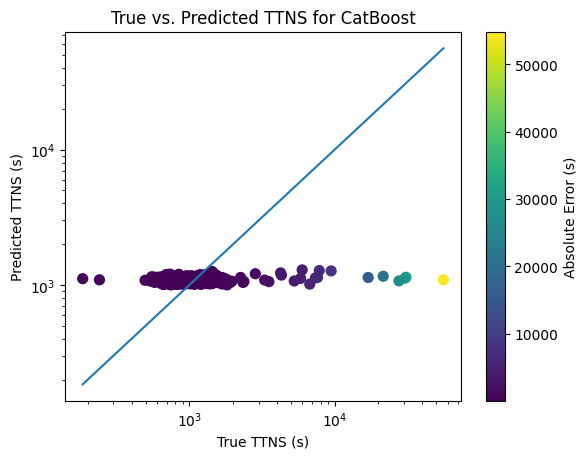

In [24]:
#Calculating multiplicative error for CatBoost
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

y_test_secs = y_test
Cat_pred_secs = CatBoost_Prediction

absolute_error_secs_Cat = np.abs(Cat_pred_secs - y_test_secs)

#absoulte_error_cat = np.abs(10**CatBoost_Prediction - y_test)
MAE_seconds = np.mean(absolute_error_secs_Cat)
print("Average Error per Record in seconds for Cat:", MAE_seconds)


#Calculating true value, predicted, and average error in terms of seconds for each event
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, Cat_pred_secs, absolute_error_secs_Cat)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, Cat_pred_secs, c=absolute_error_secs_Cat, cmap='viridis', s=50)
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for CatBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

Cat Boost Drivers: tide_deriv     19.514447
slip_size      17.691852
form_fac        4.568643
high_t_evt      1.806527
tide_height     0.000000
time_since      0.000000
dtype: float64


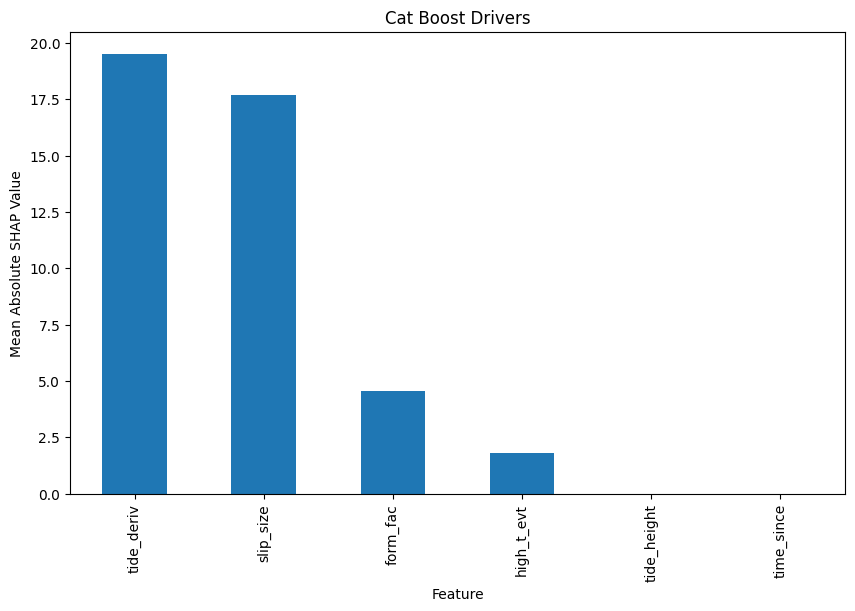

In [ ]:
# Driving parameters for Cat

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_cat = shap.TreeExplainer(CatBoost, X_shap, feature_perturbation="interventional")

shap_values_cat = explainer_cat.shap_values(X_shap)#Doing the tree analysis on Cat uisng training data

Cat_imp = pd.Series(np.abs(shap_values_cat).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)#Analysis of driving parameters in Cat

print("Cat Boost Drivers:", Cat_imp)

# Creating a bar graph showing the driving parameters for CatBoost


plt.figure(figsize=(10, 6))
Cat_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Cat Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()